# 🚚 Smart Last-Mile Delivery Platform
### Hybrid RL + ALNS Route Optimisation Engine

**Inspired by platforms like FarEye, Lalamove, and GHTK.**  
Optimises daily delivery runs for a fleet of vehicles departing from a central warehouse.

| Feature | Description |
|---|---|
| **Algorithms** | ALNS · DQN · DQN→ALNS hybrid |
| **Constraints** | Vehicle capacity · Customer time windows · Fleet size |
| **Dynamic** | Add new orders mid-session, re-optimise instantly |
| **Metrics** | On-time rate · Cost/delivery · Vehicle utilisation · Distance |
| **Dataset** | Solomon RC1/RC2 (maps to real city delivery scenarios) |

In [1]:
# ── 1. Install & Imports ──────────────────────────────────────────────────────
!pip install numba safetensors folium -q

import os, glob, time, random, math
from collections import deque
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from numba import njit

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from safetensors.torch import save_file, load_file

try:
    import folium
    HAS_FOLIUM = True
except ImportError:
    HAS_FOLIUM = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device : {DEVICE}')
print(f'✅ PyTorch: {torch.__version__}')

✅ Device : cuda
✅ PyTorch: 2.10.0+cu128


In [2]:
# ── 2. Platform Configuration ─────────────────────────────────────────────────
# --- Paths (Kaggle / Colab / Local) ---
IN_KAGGLE  = os.path.exists('/kaggle/working')
IN_COLAB   = 'google.colab' in str(globals())
DATA_PATH  = ('/kaggle/input/datasets/senju14/vrptw-benchmark-datasets/data/Solomon'
              if IN_KAGGLE else '/content/vrptw-benchmark/data/Solomon')
OUTPUT_DIR = '/kaggle/working' if IN_KAGGLE else '/content'
MODEL_DIR  = os.path.join(OUTPUT_DIR, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

# --- Logistics business settings ---
@dataclass
class PlatformConfig:
    # Fleet
    vehicle_capacity_kg: float = 500.0    # kg per vehicle
    cost_per_km: float         = 5_000    # VND per km
    fixed_vehicle_cost: float  = 200_000  # VND per vehicle/day
    max_fleet_size: int        = 25       # max dispatch-able vehicles
    depot_open_hour: int       = 6        # 06:00
    depot_close_hour: int      = 22       # 22:00

    # Algorithm
    alns_iterations: int       = 1_200
    dqn_episodes: int          = 300
    early_stop_patience: int   = 300
    n_runs: int                = 1
    seed: int                  = 42

    # ALNS hyper-params
    destroy_ratio_min: float   = 0.10
    destroy_ratio_max: float   = 0.40
    temp_control: float        = 0.05
    temp_decay: float          = 0.99975
    sigma1: int                = 33
    sigma2: int                = 9
    sigma3: int                = 3
    weight_decay: float        = 0.10
    segment_size: int          = 50

    # DQN hyper-params
    dqn_state_dim: int         = 13   # incl. TW features
    alns_state_dim: int        = 14
    hidden_dim: int            = 128
    lr: float                  = 1e-3
    gamma: float               = 0.95
    epsilon_start: float       = 0.40
    epsilon_end: float         = 0.01
    epsilon_decay: float       = 0.9997
    buffer_size: int           = 8_000
    batch_size: int            = 64
    target_update_freq: int    = 200
    train_freq: int            = 10
    reward_vehicle: float      = 5.0
    reward_cost_scale: float   = 1.0
    reward_best_bonus: float   = 2.0
    reward_infeasible: float   = -3.0

CFG = PlatformConfig()

# Solomon benchmark best-known solutions (academic validation)
BKS = {
    'RC101': {'nv': 14, 'td': 1696.94}, 'RC102': {'nv': 12, 'td': 1554.75},
    'RC103': {'nv': 11, 'td': 1261.67}, 'RC104': {'nv': 10, 'td': 1135.48},
    'RC105': {'nv': 13, 'td': 1629.44}, 'RC106': {'nv': 11, 'td': 1424.73},
    'RC107': {'nv': 11, 'td': 1230.48}, 'RC108': {'nv': 10, 'td': 1139.82},
    'RC201': {'nv': 4,  'td': 1406.94}, 'RC202': {'nv': 3,  'td': 1365.64},
    'RC203': {'nv': 3,  'td': 1049.62}, 'RC204': {'nv': 3,  'td': 798.46},
    'RC205': {'nv': 4,  'td': 1297.65}, 'RC206': {'nv': 3,  'td': 1146.32},
    'RC207': {'nv': 3,  'td': 1061.14}, 'RC208': {'nv': 3,  'td': 828.14},
}
print('✅ Config ready.')

✅ Config ready.


In [3]:
# ── 3. Logistics Data Layer ───────────────────────────────────────────────────
# Translates academic VRPTW format into real-world logistics language.
# Solomon (0–1000 units) ↔ Real (minutes from 06:00, km scaled)

SCALE_FACTOR = 1.0   # 1 unit ≈ 0.1 km in Solomon
BASE_TIME    = datetime(2024, 1, 1, 6, 0)  # depot opens at 06:00

def units_to_time(t: float) -> str:
    """Convert Solomon time unit → HH:MM string (base = 06:00)."""
    dt = BASE_TIME + timedelta(minutes=t)
    return dt.strftime('%H:%M')

def units_to_km(d: float) -> float:
    """Convert Solomon distance unit → km."""
    return round(d * SCALE_FACTOR * 0.1, 2)

def cost_vnd(distance_units: float, cfg: PlatformConfig) -> int:
    """Compute total cost in VND for a given route distance."""
    return int(units_to_km(distance_units) * cfg.cost_per_km)


class DeliveryOrder:
    """One customer delivery stop — the atomic unit of the dispatch system."""
    def __init__(self, order_id: int, x: float, y: float, demand_kg: float,
                 earliest: float, latest: float, service_min: float,
                 address: str = '', customer_name: str = '',
                 priority: str = 'normal'):
        self.order_id      = order_id
        self.x             = x
        self.y             = y
        self.demand_kg     = demand_kg
        self.earliest      = earliest   # Solomon time units from depot open
        self.latest        = latest
        self.service_min   = service_min
        self.address       = address or f'({x:.1f}, {y:.1f})'
        self.customer_name = customer_name or f'KH-{order_id:04d}'
        self.priority      = priority  # 'normal' | 'express' | 'scheduled'
        self.status        = 'pending' # pending → assigned → delivered
        self.assigned_vehicle = None
        self.eta           = None

    @property
    def tw_open(self)  -> str: return units_to_time(self.earliest)
    @property
    def tw_close(self) -> str: return units_to_time(self.latest)
    @property
    def tw_width_min(self) -> float: return self.latest - self.earliest

    def __repr__(self):
        return (f'Order({self.order_id}, {self.customer_name}, '
                f'{self.demand_kg:.0f}kg, {self.tw_open}–{self.tw_close})')


class LogisticsInstance:
    """
    Full logistics problem: depot + delivery orders + fleet.
    Wraps Solomon data but exposes business-friendly API.
    """
    def __init__(self, raw: Dict, cfg: PlatformConfig = CFG):
        self.name     = raw['name']
        self.cfg      = cfg
        data          = raw['data']
        self.capacity = raw['capacity']  # vehicle capacity in demand units

        # Node 0 = depot/warehouse
        depot_row         = data[0]
        self.depot_xy     = (depot_row[1], depot_row[2])
        self.depot_close  = depot_row[5]   # horizon
        self.horizon      = self.depot_close

        # Customers → DeliveryOrders
        self._orders: List[DeliveryOrder] = []
        for row in data[1:]:
            oid = int(row[0])
            self._orders.append(DeliveryOrder(
                order_id    = oid,
                x           = row[1], y=row[2],
                demand_kg   = row[3],
                earliest    = row[4], latest=row[5],
                service_min = row[6],
            ))

        # Pre-compute distance matrix over all nodes (0=depot)
        self.coords = data[:, 1:3]
        diff = self.coords[:, None, :] - self.coords[None, :, :]
        self.dist   = np.sqrt((diff**2).sum(axis=2))
        self.max_dist = self.dist.max()

        # Shorthand arrays (same indexing as Solomon: 0=depot, 1..n=customers)
        self.demands       = data[:, 3]
        self.ready_times   = data[:, 4]
        self.due_times     = data[:, 5]
        self.service_times = data[:, 6]
        self.n             = len(data) - 1
        self.tw_width      = self.due_times - self.ready_times
        self.max_tw_width  = self.tw_width[1:].max() + 1e-9

    @property
    def orders(self) -> List[DeliveryOrder]:
        return self._orders

    def add_order(self, order: DeliveryOrder):
        """Dynamically add a new delivery order (simulates real-time dispatch)."""
        self._orders.append(order)
        # Extend arrays — in production this would trigger a re-optimisation
        new_coord = np.array([[0, order.x, order.y, order.demand_kg,
                               order.earliest, order.latest, order.service_min]])
        new_row = new_coord[0, 1:3].reshape(1, 2)
        self.coords = np.vstack([self.coords, new_row])
        # Recompute distance matrix
        diff = self.coords[:, None, :] - self.coords[None, :, :]
        self.dist = np.sqrt((diff**2).sum(axis=2))
        self.demands       = np.append(self.demands, order.demand_kg)
        self.ready_times   = np.append(self.ready_times, order.earliest)
        self.due_times     = np.append(self.due_times, order.latest)
        self.service_times = np.append(self.service_times, order.service_min)
        self.n             += 1
        self.max_dist       = self.dist.max()
        self.tw_width       = self.due_times - self.ready_times
        self.max_tw_width   = self.tw_width[1:].max() + 1e-9
        print(f'✅ New order added: {order}')
        return self

    def summary(self):
        print(f'\n📦 Instance: {self.name}')
        print(f'   Orders: {self.n}')
        print(f'   Vehicle capacity: {self.capacity:.0f} units')
        print(f'   Depot horizon: {units_to_time(0)} – {units_to_time(self.horizon)}')
        print(f'   Avg demand/order: {self.demands[1:].mean():.1f}')
        tight = sum(1 for i in range(1, self.n+1)
                    if self.tw_width[i] < 0.2*self.horizon)
        print(f'   Tight TW orders (<20% horizon): {tight} ({tight/self.n:.0%})')


def load_datasets(base: str) -> Dict[str, List[Dict]]:
    datasets = {}
    for grp in ('rc1', 'rc2'):
        files = sorted(glob.glob(os.path.join(base, f'{grp}*.txt')))
        instances = []
        for path in files:
            with open(path) as f: lines = f.readlines()
            name     = lines[0].strip()
            capacity = float(lines[4].strip().split()[1])
            rows     = [list(map(float, l.split())) for l in lines[9:] if l.strip()]
            instances.append({'name': name, 'capacity': capacity, 'data': np.array(rows)})
        datasets[grp] = instances
        print(f'  📂 {grp.upper()}: {len(instances)} instances')
    return datasets

print('Loading datasets...')
RAW_DATASETS = load_datasets(DATA_PATH)
print(f'✅ Loaded. Sample: {RAW_DATASETS["rc1"][0]["name"]} — {len(RAW_DATASETS["rc1"][0]["data"])-1} customers')

# Wrap in LogisticsInstance objects
RC1_INSTANCES = [LogisticsInstance(d) for d in RAW_DATASETS['rc1']]
RC2_INSTANCES = [LogisticsInstance(d) for d in RAW_DATASETS['rc2']]
RC1_INSTANCES[0].summary()

Loading datasets...
  📂 RC1: 8 instances
  📂 RC2: 8 instances
✅ Loaded. Sample: RC101 — 100 customers

📦 Instance: RC101
   Orders: 100
   Vehicle capacity: 200 units
   Depot horizon: 06:00 – 10:00
   Avg demand/order: 17.2
   Tight TW orders (<20% horizon): 100 (100%)


In [4]:
# ── 4. Route & Solution Model ─────────────────────────────────────────────────
@njit(cache=True)
def _route_cost(route, dist):
    cost = dist[0, route[0]]
    for i in range(len(route) - 1):
        cost += dist[route[i], route[i + 1]]
    cost += dist[route[-1], 0]
    return cost

@njit(cache=True)
def _route_feasible(route, demands, capacity, ready, due, service, dist):
    load = 0.0
    for n in route:
        load += demands[n]
    if load > capacity:
        return False
    t, prev = 0.0, 0
    for n in route:
        t += dist[prev, n]
        if t < ready[n]: t = ready[n]
        if t > due[n]:   return False
        t += service[n]
        prev = n
    return True


class Route:
    """Single vehicle route with business metadata."""
    def __init__(self, stops: List[int], inst: LogisticsInstance,
                 vehicle_id: int = 0):
        self.stops      = stops
        self.inst       = inst
        self.vehicle_id = vehicle_id
        self._cost      = None
        self._feasible  = None

    @property
    def cost(self) -> float:
        if self._cost is None:
            arr = np.array(self.stops, dtype=np.int64)
            self._cost = float(_route_cost(arr, self.inst.dist))
        return self._cost

    @property
    def feasible(self) -> bool:
        if self._feasible is None:
            inst = self.inst
            arr  = np.array(self.stops, dtype=np.int64)
            self._feasible = bool(_route_feasible(
                arr, inst.demands, inst.capacity,
                inst.ready_times, inst.due_times, inst.service_times, inst.dist))
        return self._feasible

    @property
    def load(self) -> float:
        return sum(self.inst.demands[n] for n in self.stops)

    @property
    def utilisation(self) -> float:
        return self.load / self.inst.capacity

    def eta_schedule(self) -> List[Dict]:
        """Return ETA for every stop — the driver's schedule card."""
        inst  = self.inst
        schedule = []
        t, prev = 0.0, 0
        for stop_idx, n in enumerate(self.stops):
            t += inst.dist[prev, n]
            t = max(t, inst.ready_times[n])
            on_time = (t <= inst.due_times[n])
            schedule.append({
                'stop':        stop_idx + 1,
                'order_id':    n,
                'customer':    inst.orders[n-1].customer_name if n <= len(inst.orders) else f'C{n}',
                'arrive':      units_to_time(t),
                'window':      f"{units_to_time(inst.ready_times[n])} – {units_to_time(inst.due_times[n])}",
                'on_time':     '✅' if on_time else '⚠️ LATE',
                'load_kg':     inst.demands[n],
            })
            t += inst.service_times[n]
            prev = n
        return schedule

    def cost_vnd(self, cfg: PlatformConfig = CFG) -> int:
        return int(units_to_km(self.cost) * cfg.cost_per_km + cfg.fixed_vehicle_cost)


class DispatchPlan:
    """
    Full dispatch plan for one day = collection of routes.
    Exposes business KPIs alongside the algorithm objective.
    """
    def __init__(self, routes: List[List[int]], inst: LogisticsInstance,
                 algorithm: str = ''):
        self.inst      = inst
        self.algorithm = algorithm
        self.routes    = [r for r in routes if r]
        self._cost     = None
        self._feasible = None

    # --- core algorithm properties (used by solver) ---
    @property
    def cost(self) -> float:
        if self._cost is None:
            self._cost = sum(_route_cost(np.array(r, dtype=np.int64), self.inst.dist)
                             for r in self.routes)
        return self._cost

    @property
    def feasible(self) -> bool:
        if self._feasible is None:
            inst = self.inst
            self._feasible = all(
                _route_feasible(np.array(r, dtype=np.int64), inst.demands, inst.capacity,
                                inst.ready_times, inst.due_times, inst.service_times, inst.dist)
                for r in self.routes)
        return self._feasible

    @property
    def nv(self) -> int:
        return len(self.routes)

    def dominates(self, other: 'DispatchPlan') -> bool:
        if self.nv < other.nv:  return True
        return self.nv == other.nv and self.cost < other.cost

    def copy(self) -> 'DispatchPlan':
        return DispatchPlan([r[:] for r in self.routes], self.inst, self.algorithm)

    # --- business KPIs ---
    @property
    def total_distance_km(self) -> float:
        return units_to_km(self.cost)

    @property
    def total_cost_vnd(self) -> int:
        cfg = CFG
        return int(self.total_distance_km * cfg.cost_per_km
                   + self.nv * cfg.fixed_vehicle_cost)

    @property
    def cost_per_delivery_vnd(self) -> int:
        total_stops = sum(len(r) for r in self.routes)
        return int(self.total_cost_vnd / max(total_stops, 1))

    @property
    def on_time_rate(self) -> float:
        """Fraction of orders delivered within their time window."""
        inst = self.inst
        on_time = total = 0
        for route in self.routes:
            t, prev = 0.0, 0
            for n in route:
                t += inst.dist[prev, n]
                t = max(t, inst.ready_times[n])
                total += 1
                if t <= inst.due_times[n]: on_time += 1
                t += inst.service_times[n]
                prev = n
        return on_time / max(total, 1)

    @property
    def avg_vehicle_utilisation(self) -> float:
        if not self.routes: return 0.0
        utils = [sum(self.inst.demands[n] for n in r) / self.inst.capacity
                 for r in self.routes]
        return float(np.mean(utils))

    def kpi_summary(self):
        print(f'\n📊 Dispatch Plan — {self.algorithm}')
        print(f'   🚛 Vehicles deployed:    {self.nv}')
        print(f'   📏 Total distance:       {self.total_distance_km:.1f} km')
        print(f'   💰 Total cost:           {self.total_cost_vnd:,} VND')
        print(f'   📦 Cost/delivery:        {self.cost_per_delivery_vnd:,} VND')
        print(f'   ⏰ On-time rate:         {self.on_time_rate:.1%}')
        print(f'   📈 Avg vehicle load:     {self.avg_vehicle_utilisation:.1%}')
        print(f'   ✅ Feasible:             {self.feasible}')
        bks = BKS.get(self.inst.name, {})
        if bks:
            td_gap = (self.cost - bks['td']) / bks['td'] * 100
            nv_gap = self.nv - bks['nv']
            print(f'   📐 vs BKS:               TD {td_gap:+.1f}% | NV {nv_gap:+d}')

    def __repr__(self):
        return (f'DispatchPlan({self.algorithm}, nv={self.nv}, '
                f'dist={self.total_distance_km:.1f}km, '
                f'on_time={self.on_time_rate:.1%})')

print('✅ Data layer ready.')

✅ Data layer ready.


In [5]:
# ── 5. Routing Operators ──────────────────────────────────────────────────────

# ── Destroy (remove stops from routes) ───────────────────────────────────────
def _invalidate(plan):
    plan._cost = plan._feasible = None

def op_random_removal(plan, size):
    nodes = [n for r in plan.routes for n in r]
    removed = random.sample(nodes, min(size, len(nodes)))
    s = set(removed)
    plan.routes = [[n for n in r if n not in s] for r in plan.routes]
    plan.routes = [r for r in plan.routes if r]
    _invalidate(plan)
    return plan, removed

def op_worst_removal(plan, size):
    """Remove stops with highest detour cost — frees up most route capacity."""
    inst = plan.inst
    costs = []
    for route in plan.routes:
        for i, node in enumerate(route):
            prev = route[i-1] if i > 0 else 0
            nxt  = route[i+1] if i < len(route)-1 else 0
            savings = inst.dist[prev,node]+inst.dist[node,nxt]-inst.dist[prev,nxt]
            costs.append((savings, node))
    costs.sort(reverse=True)
    removed = [n for _,n in costs[:size]]
    s = set(removed)
    plan.routes = [[n for n in r if n not in s] for r in plan.routes]
    plan.routes = [r for r in plan.routes if r]
    _invalidate(plan)
    return plan, removed

def op_shaw_removal(plan, size):
    """Group similar customers together — encourages route consolidation."""
    inst = plan.inst
    nodes = [n for r in plan.routes for n in r]
    if not nodes: return plan, []
    seed = random.choice(nodes)
    removed, rset = [seed], {seed}
    max_d  = inst.max_dist + 1e-9
    max_tw = max(inst.due_times - inst.ready_times) + 1e-9
    max_dm = inst.demands.max() + 1e-9
    while len(removed) < size:
        cands = [(n, 0.5*inst.dist[seed,n]/max_d
                     + 0.4*abs(inst.ready_times[seed]-inst.ready_times[n])/max_tw
                     + 0.1*abs(inst.demands[seed]-inst.demands[n])/max_dm)
                 for n in nodes if n not in rset]
        if not cands: break
        removed.append(min(cands, key=lambda x: x[1])[0])
        rset.add(removed[-1])
    s = set(removed)
    plan.routes = [[n for n in r if n not in s] for r in plan.routes]
    plan.routes = [r for r in plan.routes if r]
    _invalidate(plan)
    return plan, removed

def op_route_removal(plan, size):
    """Remove the smallest routes entirely — targets vehicle count reduction."""
    if len(plan.routes) <= 1: return op_random_removal(plan, size)
    removed, to_rm = [], set()
    for idx, route in sorted(enumerate(plan.routes), key=lambda x: len(x[1])):
        if len(removed) + len(route) <= size * 1.5:
            removed.extend(route); to_rm.add(idx)
        if len(removed) >= size: break
    plan.routes = [r for i,r in enumerate(plan.routes) if i not in to_rm] or [[]]
    _invalidate(plan)
    return plan, removed

def op_tw_urgency_removal(plan, size):
    """Remove orders with tightest delivery windows — prioritises SLA-critical stops."""
    inst = plan.inst
    nodes = [n for r in plan.routes for n in r]
    if not nodes: return plan, []
    urgency = sorted(nodes, key=lambda n: inst.due_times[n] - inst.ready_times[n])
    removed = urgency[:size]
    s = set(removed)
    plan.routes = [[n for n in r if n not in s] for r in plan.routes]
    plan.routes = [r for r in plan.routes if r]
    _invalidate(plan)
    return plan, removed


# ── Repair (re-insert removed stops) ─────────────────────────────────────────
def _check_route(route, inst):
    arr = np.array(route, dtype=np.int64)
    return bool(_route_feasible(
        arr, inst.demands, inst.capacity,
        inst.ready_times, inst.due_times, inst.service_times, inst.dist))

def _best_insert(node, route, inst):
    best_c, best_p = float('inf'), None
    for pos in range(len(route)+1):
        prev = route[pos-1] if pos > 0 else 0
        nxt  = route[pos]   if pos < len(route) else 0
        c    = inst.dist[prev,node]+inst.dist[node,nxt]-inst.dist[prev,nxt]
        if c < best_c and _check_route(route[:pos]+[node]+route[pos:], inst):
            best_c, best_p = c, pos
    return best_c, best_p

def _insert_node(plan, node, inst):
    best_c, best_r, best_p = float('inf'), None, None
    for r_idx, route in enumerate(plan.routes):
        c, p = _best_insert(node, route, inst)
        if p is not None and c < best_c:
            best_c, best_r, best_p = c, r_idx, p
    if best_r is not None: plan.routes[best_r].insert(best_p, node)
    else: plan.routes.append([node])
    _invalidate(plan)

def op_greedy_insertion(plan, removed):
    """Insert stops sorted by deadline (most urgent first)."""
    inst = plan.inst
    for node in sorted(removed, key=lambda n: inst.due_times[n]):
        _insert_node(plan, node, inst)
    return DispatchPlan(plan.routes, inst, plan.algorithm)

def _regret_insert(plan, removed, k):
    inst = plan.inst
    remaining = removed[:]
    while remaining:
        best_regret, chosen, chosen_ins = -float('inf'), None, None
        for node in remaining:
            opts = sorted((c,r,p) for r,route in enumerate(plan.routes)
                          for c,p in [_best_insert(node,route,inst)] if p is not None)
            if len(opts) >= k:   regret = sum(opts[i][0]-opts[0][0] for i in range(1,k))
            elif len(opts) >= 2: regret = opts[1][0]-opts[0][0]
            elif len(opts) == 1: regret = float('inf')
            else:                regret = -float('inf')
            if regret > best_regret and opts:
                best_regret, chosen, chosen_ins = regret, node, opts[0]
        if chosen is not None:
            _, r_idx, pos = chosen_ins
            plan.routes[r_idx].insert(pos, chosen)
            _invalidate(plan)
            remaining.remove(chosen)
        else:
            for node in remaining: plan.routes.append([node])
            break
    return DispatchPlan(plan.routes, inst, plan.algorithm)

def op_regret2_insertion(plan, removed): return _regret_insert(plan, removed, 2)
def op_regret3_insertion(plan, removed): return _regret_insert(plan, removed, 3)

def op_tw_greedy_insertion(plan, removed):
    """Insert tightest-TW orders first — prevents cascading SLA failures."""
    inst = plan.inst
    for node in sorted(removed, key=lambda n: inst.due_times[n]-inst.ready_times[n]):
        _insert_node(plan, node, inst)
    return DispatchPlan(plan.routes, inst, plan.algorithm)

DESTROY_OPS = [op_random_removal, op_worst_removal, op_shaw_removal,
               op_route_removal, op_tw_urgency_removal]
REPAIR_OPS  = [op_greedy_insertion, op_regret2_insertion,
               op_regret3_insertion, op_tw_greedy_insertion]
N_D, N_R    = len(DESTROY_OPS), len(REPAIR_OPS)
print(f'✅ Operators: {N_D} destroy × {N_R} repair = {N_D*N_R} combos')

✅ Operators: 5 destroy × 4 repair = 20 combos


In [6]:
# ── 6. Routing Helpers ────────────────────────────────────────────────────────
def build_initial_plan(inst: LogisticsInstance, algorithm='') -> DispatchPlan:
    """Earliest-deadline-first greedy construction."""
    customers = sorted(range(1, inst.n+1), key=lambda n: (inst.due_times[n], inst.ready_times[n]))
    unvisited = set(customers)
    routes = []
    while unvisited:
        route, node, load, t = [], 0, 0.0, 0.0
        while unvisited:
            feasible = [n for n in unvisited
                        if load+inst.demands[n] <= inst.capacity
                        and t+inst.dist[node,n] <= inst.due_times[n]]
            if not feasible: break
            nxt = min(feasible, key=lambda n: inst.dist[node,n])
            route.append(nxt); unvisited.remove(nxt)
            load += inst.demands[nxt]
            t = max(t+inst.dist[node,nxt], inst.ready_times[nxt]) + inst.service_times[nxt]
            node = nxt
        if route: routes.append(route)
    return DispatchPlan(routes, inst, algorithm)

def accept_plan(current: DispatchPlan, candidate: DispatchPlan, temp: float) -> bool:
    if not candidate.feasible: return False
    if candidate.nv < current.nv:  return True
    if candidate.nv == current.nv:
        if candidate.cost < current.cost: return True
        return random.random() < math.exp(-(candidate.cost-current.cost)/max(temp,1e-6))
    return False

def destroy_size(it, cfg: PlatformConfig, n: int) -> int:
    ratio = cfg.destroy_ratio_max - (cfg.destroy_ratio_max - cfg.destroy_ratio_min)*(it/cfg.alns_iterations)
    return max(3, int(ratio*n))

print('✅ Helpers ready.')

✅ Helpers ready.


In [7]:
# ── 7. Neural Networks ────────────────────────────────────────────────────────
class DQNNet(nn.Module):
    def __init__(self, state_dim, action_dim, hidden):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.LayerNorm(hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),    nn.ReLU(),
            nn.Linear(hidden, action_dim))
    def forward(self, x): return self.net(x)

class DoubleDQNNet(nn.Module):
    """Dueling network — separates state-value from action-advantage."""
    def __init__(self, state_dim, action_dim, hidden):
        super().__init__()
        self.feature   = nn.Sequential(nn.Linear(state_dim, hidden), nn.LayerNorm(hidden), nn.ReLU())
        self.value     = nn.Sequential(nn.Linear(hidden, hidden//2), nn.ReLU(), nn.Linear(hidden//2, 1))
        self.advantage = nn.Sequential(nn.Linear(hidden, hidden//2), nn.ReLU(), nn.Linear(hidden//2, action_dim))
    def forward(self, x):
        f = self.feature(x); v = self.value(f); a = self.advantage(f)
        return v + a - a.mean(dim=-1, keepdim=True)

class ReplayBuffer:
    def __init__(self, capacity): self.buf = deque(maxlen=capacity)
    def push(self, s, a, r, ns, done): self.buf.append((s,a,r,ns,done))
    def sample(self, k):
        batch = random.sample(self.buf, k)
        s,a,r,ns,d = zip(*batch)
        return (np.array(s,dtype=np.float32), np.array(a,dtype=np.int64),
                np.array(r,dtype=np.float32), np.array(ns,dtype=np.float32),
                np.array(d,dtype=np.float32))
    def __len__(self): return len(self.buf)

print('✅ Neural networks ready.')

✅ Neural networks ready.


In [8]:
# ── 8. ALNS Solver ───────────────────────────────────────────────────────────
class ALNSSolver:
    """
    Adaptive Large Neighbourhood Search.
    Used as both a standalone solver and as the metaheuristic backbone
    in the hybrid DQN→ALNS pipeline.
    """
    def __init__(self, inst: LogisticsInstance, cfg: PlatformConfig = CFG):
        self.inst = inst; self.cfg = cfg

    def _roulette(self, w):
        p = w/w.sum(); return int(np.random.choice(len(w), p=p))

    def solve(self, initial_plan: DispatchPlan = None,
              seed: int = None, verbose: bool = False) -> Tuple[DispatchPlan, List[float]]:
        if seed is not None: random.seed(seed); np.random.seed(seed)
        cfg = self.cfg
        current = initial_plan.copy() if initial_plan else build_initial_plan(self.inst, 'ALNS')
        current.algorithm = 'ALNS'
        best = current.copy()
        temp = cfg.temp_control * current.cost / math.log(2)
        d_w = np.ones(N_D); r_w = np.ones(N_R)
        seg_s = np.zeros((N_D,N_R)); seg_c = np.zeros((N_D,N_R))
        history = [best.cost]; no_improve = 0

        for it in range(cfg.alns_iterations):
            d_idx = self._roulette(d_w); r_idx = self._roulette(r_w)
            size  = destroy_size(it, cfg, self.inst.n)
            destroyed, removed = DESTROY_OPS[d_idx](current.copy(), size)
            candidate = REPAIR_OPS[r_idx](destroyed, removed)

            score = 0
            if accept_plan(current, candidate, temp):
                if candidate.dominates(best):    best=candidate.copy(); score=cfg.sigma1; no_improve=0
                elif candidate.dominates(current): score=cfg.sigma2; no_improve=0
                else:                              score=cfg.sigma3; no_improve+=1
                current = candidate
            else: no_improve += 1

            seg_s[d_idx,r_idx] += score; seg_c[d_idx,r_idx] += 1
            if (it+1) % cfg.segment_size == 0:
                for d in range(N_D):
                    for r in range(N_R):
                        if seg_c[d,r] > 0:
                            avg = seg_s[d,r]/seg_c[d,r]
                            d_w[d] = d_w[d]*(1-cfg.weight_decay) + avg*cfg.weight_decay
                            r_w[r] = r_w[r]*(1-cfg.weight_decay) + avg*cfg.weight_decay
                seg_s[:]=0; seg_c[:]=0
                d_w = np.maximum(d_w, 0.1); r_w = np.maximum(r_w, 0.1)

            temp *= cfg.temp_decay; history.append(best.cost)
            if no_improve >= cfg.early_stop_patience:
                if verbose: print(f'  Early stop @ iter {it}')
                break

        best.algorithm = 'ALNS'
        return best, history

print('✅ ALNS solver ready.')

✅ ALNS solver ready.


In [9]:
# ── 9. DQN → ALNS Hybrid (main pipeline) ─────────────────────────────────────
#
# FLOW:
#  1. DQN builds an initial solution constructively (route-by-route)
#  2. That solution is fed as the STARTING POINT to ALNS
#  3. ALNS polishes it with destroy/repair cycles
#
# This is better than running ALNS from scratch because the DQN warm-start
# is smarter than the simple greedy construction, giving ALNS a better
# initial neighbourhood to search.

class DQNConstructor:
    """
    Phase 1: DQN builds routes one stop at a time.
    State includes TW-specific features so the agent avoids
    leaving urgent deliveries stranded.
    """
    def __init__(self, inst: LogisticsInstance, cfg: PlatformConfig = CFG):
        self.inst = inst; self.cfg = cfg
        self.state_dim  = cfg.dqn_state_dim   # 13D
        self.action_dim = inst.n + 1
        self.q   = DQNNet(self.state_dim, self.action_dim, cfg.hidden_dim).to(DEVICE)
        self.q_t = DQNNet(self.state_dim, self.action_dim, cfg.hidden_dim).to(DEVICE)
        self.q_t.load_state_dict(self.q.state_dict())
        self.opt = optim.Adam(self.q.parameters(), lr=cfg.lr)
        self.buf = ReplayBuffer(cfg.buffer_size)
        self.eps = cfg.epsilon_start

    def _state(self, node, visited, load, t):
        inst = self.inst
        unvisited = inst.n - len(visited)
        feasible_nodes = [
            n for n in range(1, inst.n+1)
            if n not in visited
            and load+inst.demands[n] <= inst.capacity
            and t+inst.dist[node,n]  <= inst.due_times[n]
        ]
        n_feas = len(feasible_nodes)
        if feasible_nodes:
            slacks       = [inst.due_times[n] - (t + inst.dist[node,n]) for n in feasible_nodes]
            min_sl       = min(slacks) / max(inst.horizon, 1)
            avg_sl       = (sum(slacks)/len(slacks)) / max(inst.horizon, 1)
            tight_thresh = 0.10 * inst.horizon
            urgent_frac  = sum(1 for s in slacks if s < tight_thresh) / max(n_feas, 1)
            avg_tw_w     = (sum(inst.tw_width[n] for n in feasible_nodes) / n_feas
                           ) / max(inst.max_tw_width, 1)
        else:
            min_sl = avg_sl = urgent_frac = avg_tw_w = 0.0
        return np.array([
            load/inst.capacity,
            t/max(inst.horizon,1),
            len(visited)/inst.n,
            (inst.capacity-load)/inst.capacity,
            unvisited/inst.n,
            n_feas/max(unvisited,1),
            inst.coords[node,0]/100,
            inst.coords[node,1]/100,
            inst.demands[node]/inst.capacity,
            min_sl, avg_sl, urgent_frac, avg_tw_w,   # TW features
        ], dtype=np.float32)

    def _feasible_actions(self, node, visited, load, t):
        inst = self.inst; actions = [0]
        for n in range(1, inst.n+1):
            if (n not in visited
                    and load+inst.demands[n] <= inst.capacity
                    and t+inst.dist[node,n]  <= inst.due_times[n]):
                actions.append(n)
        return actions

    def _select(self, state, feasible):
        if random.random() < self.eps: return random.choice(feasible)
        with torch.no_grad():
            q = self.q(torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(DEVICE)).cpu().numpy()[0]
        return max(feasible, key=lambda a: q[a])

    def _train_step(self):
        if len(self.buf) < self.cfg.batch_size: return
        s,a,r,ns,d = self.buf.sample(self.cfg.batch_size)
        s=torch.tensor(s).to(DEVICE); a=torch.tensor(a,dtype=torch.long).to(DEVICE)
        r=torch.tensor(r).to(DEVICE); ns=torch.tensor(ns).to(DEVICE); d=torch.tensor(d).to(DEVICE)
        q_pred = self.q(s).gather(1,a.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            target = r + self.cfg.gamma * self.q_t(ns).max(1)[0] * (1-d)
        loss = F.mse_loss(q_pred, target)
        self.opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(self.q.parameters(), 1.0); self.opt.step()

    def _run_episode(self):
        inst = self.inst; visited = set(); routes = []; transitions = []
        while len(visited) < inst.n:
            route, node, load, t = [], 0, 0.0, 0.0
            while True:
                state    = self._state(node, visited, load, t)
                feasible = self._feasible_actions(node, visited, load, t)
                if len(feasible) == 1: break
                action = self._select(state, feasible)
                if action == 0: break
                dist_val = inst.dist[node, action]
                # Reward: minimise distance, bonus for urgent TW deliveries
                tw_slack = inst.due_times[action] - (t + dist_val)
                tightness = 1.0 - min(tw_slack / max(inst.horizon,1), 1.0)
                reward = -dist_val/max(inst.max_dist,1) + 0.5*tightness
                load += inst.demands[action]
                t = max(t+dist_val, inst.ready_times[action]) + inst.service_times[action]
                visited.add(action); route.append(action)
                ns   = self._state(action, visited, load, t)
                done = (len(visited) == inst.n)
                transitions.append((state, action, reward, ns, float(done)))
                node = action
            if route: routes.append(route)
        return DispatchPlan(routes, inst, 'DQN'), transitions

    def train(self, seed=None, verbose=False) -> Tuple[DispatchPlan, List[float]]:
        if seed is not None: random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
        best_plan = None; best_cost = float('inf'); history = []
        self.eps  = self.cfg.epsilon_start
        n_ep      = max(50, self.cfg.alns_iterations // self.inst.n)

        for ep in range(n_ep):
            plan, transitions = self._run_episode()
            if plan.feasible and transitions:
                bonus = max(0,(best_cost-plan.cost)/best_cost*10) if best_cost<float('inf') else 1.0
                s,a,r,ns,d = transitions[-1]; transitions[-1]=(s,a,r+bonus,ns,d)
                if plan.cost < best_cost: best_cost=plan.cost; best_plan=plan.copy()
            for tr in transitions: self.buf.push(*tr)
            if ep % 5 == 0:
                for _ in range(min(10, len(self.buf)//max(self.cfg.batch_size,1))): self._train_step()
            if ep % 20 == 0: self.q_t.load_state_dict(self.q.state_dict())
            self.eps = max(self.cfg.epsilon_end, self.eps*self.cfg.epsilon_decay)
            history.append(best_cost if best_cost<float('inf') else float('nan'))

        if best_plan is None: best_plan = build_initial_plan(self.inst, 'DQN')
        return best_plan, history

    def save(self, path): save_file({k:v.cpu() for k,v in self.q.state_dict().items()}, path)
    def load(self, path): self.q.load_state_dict(load_file(path)); self.q_t.load_state_dict(self.q.state_dict())


class DQNALNSSolver:
    """
    Phase 1: DQN builds a warm-start solution.
    Phase 2: ALNS polishes it from that warm start.
    Combined result should beat either algorithm alone.
    """
    def __init__(self, inst: LogisticsInstance, cfg: PlatformConfig = CFG):
        self.inst = inst; self.cfg = cfg
        self.dqn  = DQNConstructor(inst, cfg)
        self.alns = ALNSSolver(inst, cfg)

    def solve(self, seed=None, verbose=False) -> Tuple[DispatchPlan, Dict]:
        if verbose: print('  [Phase 1] DQN warm-start...')
        dqn_plan, dqn_hist = self.dqn.train(seed=seed, verbose=verbose)

        if verbose:
            print(f'  [Phase 1] Done. nv={dqn_plan.nv}, cost={dqn_plan.cost:.1f}')
            print('  [Phase 2] ALNS refinement...')
        alns_plan, alns_hist = self.alns.solve(initial_plan=dqn_plan, seed=seed, verbose=verbose)

        alns_plan.algorithm = 'DQN→ALNS'
        return alns_plan, {'dqn': dqn_hist, 'alns': alns_hist, 'dqn_plan': dqn_plan}

    def save(self, path): self.dqn.save(path)
    def load(self, path): self.dqn.load(path)

print('✅ DQN → ALNS hybrid ready.')

✅ DQN → ALNS hybrid ready.


In [10]:
# ── 10. Visualisation ─────────────────────────────────────────────────────────
ROUTE_COLORS = [
    '#E63946','#2A9D8F','#E9C46A','#264653','#F4A261',
    '#A8DADC','#457B9D','#6A4C93','#F72585','#4CC9F0',
    '#80B918','#FF9F1C','#CBFF8C','#8338EC','#3A86FF',
]

def visualise_plan(plan: DispatchPlan, title: str = '', figsize=(13, 10)):
    inst = plan.inst
    fig, ax = plt.subplots(figsize=figsize)

    # Depot
    depot = inst.coords[0]
    ax.scatter(*depot, s=250, c='black', marker='s', zorder=5, label='🏭 Warehouse')
    ax.annotate('DEPOT', depot, fontsize=8, ha='center', va='bottom', fontweight='bold')

    # Routes
    for i, route in enumerate(plan.routes):
        col = ROUTE_COLORS[i % len(ROUTE_COLORS)]
        stops = [0] + route + [0]
        xs = [inst.coords[n, 0] for n in stops]
        ys = [inst.coords[n, 1] for n in stops]
        ax.plot(xs, ys, '-o', color=col, linewidth=1.5, markersize=5,
                alpha=0.8, label=f'V{i+1} ({len(route)} stops)')
        # Annotate first stop
        if route:
            n0 = route[0]
            ax.annotate(f'V{i+1}', inst.coords[n0], fontsize=7, color=col,
                        ha='right', va='top')

    ax.set_title(title or f'{plan.algorithm} — {inst.name}\n'
                          f'{plan.nv} vehicles · {plan.total_distance_km:.1f} km · '
                          f'On-time: {plan.on_time_rate:.1%}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('X-coordinate'); ax.set_ylabel('Y-coordinate')
    ax.legend(loc='upper right', fontsize=7, ncol=2, framealpha=0.9)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


def compare_plans(*plans: DispatchPlan):
    """Side-by-side KPI comparison dashboard."""
    rows = []
    for p in plans:
        bks = BKS.get(p.inst.name, {})
        td_gap = ((p.cost - bks['td'])/bks['td']*100) if bks else None
        nv_gap = (p.nv - bks['nv']) if bks else None
        rows.append({
            'Algorithm':          p.algorithm,
            'Vehicles':           p.nv,
            'NV vs BKS':          f"{nv_gap:+d}" if nv_gap is not None else '—',
            'Distance (km)':      f"{p.total_distance_km:.1f}",
            'TD gap vs BKS':      f"{td_gap:+.1f}%" if td_gap is not None else '—',
            'Total cost (VND)':   f"{p.total_cost_vnd:,}",
            'Cost/delivery (VND)':f"{p.cost_per_delivery_vnd:,}",
            'On-time rate':       f"{p.on_time_rate:.1%}",
            'Avg vehicle load':   f"{p.avg_vehicle_utilisation:.1%}",
            'Feasible':           '✅' if p.feasible else '❌',
        })
    df = pd.DataFrame(rows).set_index('Algorithm')
    print(df.to_string())
    return df


def print_driver_schedule(plan: DispatchPlan, vehicle_idx: int = 0):
    """Print the detailed schedule card for one driver."""
    if vehicle_idx >= len(plan.routes):
        print(f'Vehicle {vehicle_idx} not found.')
        return
    route = Route(plan.routes[vehicle_idx], plan.inst, vehicle_id=vehicle_idx+1)
    schedule = route.eta_schedule()
    print(f'\n🚛 Driver Schedule — Vehicle {vehicle_idx+1} | {plan.algorithm}')
    print(f'   Depot departure: {units_to_time(0)} | Total: {len(schedule)} stops')
    print(f'   Load: {route.load:.0f}/{plan.inst.capacity:.0f} units '
          f'({route.utilisation:.1%}) | Distance: {units_to_km(route.cost):.1f} km')
    print(f'   Cost estimate: {route.cost_vnd():,} VND')
    print()
    df = pd.DataFrame(schedule)
    print(df.to_string(index=False))

print('✅ Visualisation ready.')

✅ Visualisation ready.


In [11]:
# ── 11. Dispatch Engine — Real-time Order Management ─────────────────────────

class DispatchEngine:
    """
    High-level logistics platform API.
    Manages the full daily dispatch cycle:
      load orders → choose algorithm → optimise → re-route on new orders.
    """
    def __init__(self, inst: LogisticsInstance, cfg: PlatformConfig = CFG):
        self.inst   = inst
        self.cfg    = cfg
        self._plan  = None
        self._logs: List[Dict] = []

    @property
    def current_plan(self) -> Optional[DispatchPlan]:
        return self._plan

    def optimise(self, algorithm: str = 'DQN→ALNS',
                 seed: int = None, verbose: bool = False) -> DispatchPlan:
        """
        Run selected algorithm and return the dispatch plan.

        algorithm:
          'ALNS'     — standard ALNS baseline
          'DQN'      — DQN constructive only
          'DQN→ALNS' — hybrid (recommended)
        """
        t0 = time.time()
        print(f'\n🔧 Running {algorithm} on {self.inst.name}...')

        if algorithm == 'ALNS':
            solver = ALNSSolver(self.inst, self.cfg)
            plan, history = solver.solve(seed=seed, verbose=verbose)
        elif algorithm == 'DQN':
            solver = DQNConstructor(self.inst, self.cfg)
            plan, history = solver.train(seed=seed, verbose=verbose)
        elif algorithm in ('DQN→ALNS', 'DQN+ALNS'):
            solver = DQNALNSSolver(self.inst, self.cfg)
            plan, meta = solver.solve(seed=seed, verbose=verbose)
            history = meta.get('alns', [])
        else:
            raise ValueError(f'Unknown algorithm: {algorithm}')

        elapsed = time.time() - t0
        self._plan = plan
        self._logs.append({
            'algorithm': algorithm,
            'time_s':    round(elapsed, 1),
            'nv':        plan.nv,
            'cost_km':   plan.total_distance_km,
            'on_time':   plan.on_time_rate,
        })
        print(f'✅ Done in {elapsed:.1f}s')
        plan.kpi_summary()
        return plan

    def add_order(self, x: float, y: float, demand_kg: float,
                  earliest_hhmm: str, latest_hhmm: str,
                  service_min: float = 15.0,
                  customer_name: str = '',
                  priority: str = 'normal',
                  re_optimise: bool = True) -> DeliveryOrder:
        """
        Add a new order during the day and optionally re-optimise routes.
        earliest_hhmm / latest_hhmm format: 'HH:MM'
        """
        def hhmm_to_units(hhmm: str) -> float:
            h, m = map(int, hhmm.split(':'))
            # Convert to minutes from 06:00
            return (h - CFG.depot_open_hour) * 60 + m

        new_id = self.inst.n + 1
        order  = DeliveryOrder(
            order_id      = new_id,
            x=x, y=y,
            demand_kg     = demand_kg,
            earliest      = hhmm_to_units(earliest_hhmm),
            latest        = hhmm_to_units(latest_hhmm),
            service_min   = service_min,
            customer_name = customer_name or f'KH-{new_id:04d}',
            priority      = priority,
        )
        self.inst.add_order(order)

        if re_optimise and self._plan is not None:
            print('  🔄 Re-optimising with new order...')
            self.optimise(algorithm=self._plan.algorithm or 'ALNS')

        return order

    def run_day(self, algorithm: str = 'DQN→ALNS', seed: int = 42) -> DispatchPlan:
        """Full day simulation: optimise → print schedule → visualise."""
        plan = self.optimise(algorithm=algorithm, seed=seed)
        visualise_plan(plan)
        print_driver_schedule(plan, 0)  # Print first driver's card
        return plan

print('✅ Dispatch engine ready.')

✅ Dispatch engine ready.


In [12]:
# ── 12. Benchmark Experiment ──────────────────────────────────────────────────

def run_benchmark(instances: List[LogisticsInstance],
                  algorithms: List[str] = ['ALNS', 'DQN', 'DQN→ALNS'],
                  cfg: PlatformConfig = CFG) -> pd.DataFrame:
    """
    Run all algorithms across all instances.
    Saves results incrementally so you can resume after interruptions.
    """
    result_path = os.path.join(OUTPUT_DIR, 'benchmark_results.csv')
    if os.path.exists(result_path):
        existing = pd.read_csv(result_path)
        done = set(zip(existing['Instance'], existing['Algorithm']))
        print(f'Resuming — {len(done)} combos done')
    else:
        done = set()

    for inst in instances:
        for algo in algorithms:
            if (inst.name, algo) in done:
                print(f'  ⏭ Skip {inst.name} — {algo}'); continue

            print(f'\n[{inst.name}] {algo}')
            engine = DispatchEngine(inst, cfg)
            t0   = time.time()
            plan = engine.optimise(algorithm=algo, seed=cfg.seed)
            elapsed = time.time() - t0

            bks = BKS.get(inst.name, {})
            td_gap = (plan.cost - bks['td'])/bks['td']*100 if bks.get('td') else None
            nv_gap = plan.nv - bks['nv'] if bks.get('nv') else None

            row = pd.DataFrame([{
                'Dataset':     'RC1' if 'RC1' in inst.name else 'RC2',
                'Instance':    inst.name,
                'Algorithm':   algo,
                'NV':          plan.nv,
                'NV_diff':     nv_gap,
                'TD':          round(plan.cost, 2),
                'Gap%':        round(td_gap, 2) if td_gap is not None else None,
                'Distance_km': round(plan.total_distance_km, 1),
                'Cost_VND':    plan.total_cost_vnd,
                'OnTime%':     round(plan.on_time_rate*100, 1),
                'VehicleUtil%':round(plan.avg_vehicle_utilisation*100, 1),
                'Time_s':      round(elapsed, 1),
                'Feasible':    plan.feasible,
            }])
            row.to_csv(result_path, mode='a', header=not os.path.exists(result_path), index=False)
            print(f'  → {repr(plan)}')

    return pd.read_csv(result_path)


def print_benchmark_table(df: pd.DataFrame):
    """Academic-style summary table (for the paper)."""
    summary = (
        df.groupby(['Dataset','Algorithm'])
          .agg(NV=('NV','mean'), TD=('TD','mean'), Gap=('Gap%','mean'),
               NV_diff=('NV_diff','mean'),
               OnTime=('OnTime%','mean'),
               VehUtil=('VehicleUtil%','mean'),
               Time=('Time_s','mean'))
          .round(2).reset_index()
    )
    hdr = f'{"Dataset":<8}{"Algorithm":<14}{"NV":>5}{"NV+/-":>7}{"TD":>10}{"Gap%":>8}{"On-time":>9}{"V.Util":>8}{"Time":>8}'
    print('\n' + hdr)
    print('-' * len(hdr))
    for _, r in summary.iterrows():
        diff = f"{r['NV_diff']:+.1f}" if pd.notna(r['NV_diff']) else '—'
        gap  = f"{r['Gap']:+.1f}%"    if pd.notna(r['Gap'])     else '—'
        print(f"{r['Dataset']:<8}{r['Algorithm']:<14}{r['NV']:>5.1f}{diff:>7}"
              f"{r['TD']:>10.1f}{gap:>8}{r['OnTime']:>8.1f}%{r['VehUtil']:>7.1f}%{r['Time']:>7.1f}s")

print('✅ Benchmark runner ready.')

✅ Benchmark runner ready.



🔧 Running DQN→ALNS on RC101...
✅ Done in 79.6s

📊 Dispatch Plan — DQN→ALNS
   🚛 Vehicles deployed:    15
   📏 Total distance:       166.6 km
   💰 Total cost:           3,832,750 VND
   📦 Cost/delivery:        38,327 VND
   ⏰ On-time rate:         100.0%
   📈 Avg vehicle load:     57.5%
   ✅ Feasible:             True
   📐 vs BKS:               TD -1.9% | NV +1


/tmp/ipykernel_24/3067751467.py:38: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


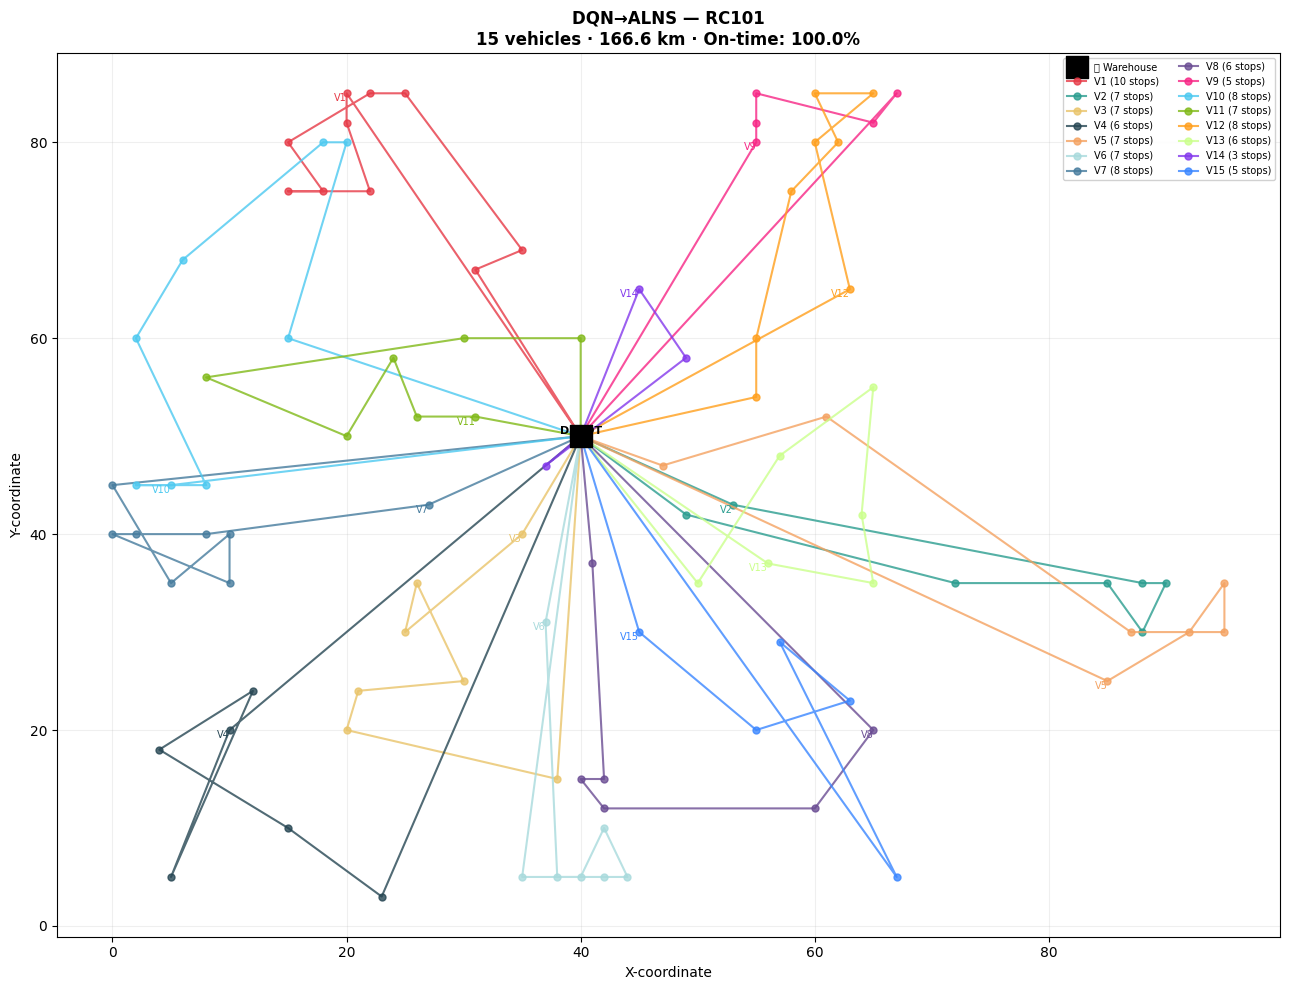


🚛 Driver Schedule — Vehicle 1 | DQN→ALNS
   Depot departure: 06:00 | Total: 10 stops
   Load: 166/200 units (83.0%) | Distance: 12.1 km
   Cost estimate: 260,300 VND

 stop  order_id customer arrive        window on_time  load_kg
    1         5  KH-0005  06:41 06:41 – 07:11       ✅     20.0
    2        45  KH-0045  06:54 06:37 – 07:07       ✅     10.0
    3         2  KH-0002  07:11 06:50 – 07:20       ✅     30.0
    4         7  KH-0007  07:28 07:19 – 07:49       ✅     20.0
    5         6  KH-0006  07:41 07:35 – 08:05       ✅     20.0
    6         8  KH-0008  07:57 07:31 – 08:01       ✅     10.0
    7         3  KH-0003  08:15 07:49 – 08:19       ✅     10.0
    8         1  KH-0001  08:28 08:25 – 08:55       ✅     20.0
    9        70  KH-0070  09:00 09:00 – 09:30       ✅     23.0
   10       100  KH-0100  09:14 09:00 – 09:30       ✅      3.0


In [13]:
# ── 13. 🎮 DEMO — Quick Single-Instance Run ────────────────────────────────────
# Change the instance index and algorithm to experiment.

DEMO_INSTANCE = RC1_INSTANCES[0]   # RC101
DEMO_ALGO     = 'DQN→ALNS'        # 'ALNS' | 'DQN' | 'DQN→ALNS'

engine = DispatchEngine(DEMO_INSTANCE, CFG)
plan   = engine.optimise(algorithm=DEMO_ALGO, seed=42, verbose=False)
visualise_plan(plan)
print_driver_schedule(plan, vehicle_idx=0)

In [14]:
# ── 14. Compare All 3 Algorithms on One Instance ──────────────────────────────
inst = RC1_INSTANCES[0]   # RC101 — swap for any instance

plans = []
for algo in ['ALNS', 'DQN', 'DQN→ALNS']:
    eng  = DispatchEngine(inst, CFG)
    p    = eng.optimise(algorithm=algo, seed=42)
    plans.append(p)

print('\n' + '='*60)
print('📊 ALGORITHM COMPARISON')
print('='*60)
compare_plans(*plans)


🔧 Running ALNS on RC101...
✅ Done in 70.3s

📊 Dispatch Plan — ALNS
   🚛 Vehicles deployed:    15
   📏 Total distance:       172.2 km
   💰 Total cost:           3,860,850 VND
   📦 Cost/delivery:        38,608 VND
   ⏰ On-time rate:         100.0%
   📈 Avg vehicle load:     57.5%
   ✅ Feasible:             True
   📐 vs BKS:               TD +1.5% | NV +1

🔧 Running DQN on RC101...
✅ Done in 2.2s

📊 Dispatch Plan — DQN
   🚛 Vehicles deployed:    31
   📏 Total distance:       358.0 km
   💰 Total cost:           7,989,800 VND
   📦 Cost/delivery:        79,898 VND
   ⏰ On-time rate:         100.0%
   📈 Avg vehicle load:     27.8%
   ✅ Feasible:             True
   📐 vs BKS:               TD +110.9% | NV +17

🔧 Running DQN→ALNS on RC101...
✅ Done in 72.1s

📊 Dispatch Plan — DQN→ALNS
   🚛 Vehicles deployed:    16
   📏 Total distance:       169.0 km
   💰 Total cost:           4,045,000 VND
   📦 Cost/delivery:        40,450 VND
   ⏰ On-time rate:         100.0%
   📈 Avg vehicle load:     53.9%


,Vehicles,NV vs BKS,Distance (km),TD gap vs BKS,Total cost (VND),Cost/delivery (VND),On-time rate,Avg vehicle load,Feasible
Algorithm,,,,,,,,,
ALNS,15,+1,172.2,+1.5%,"3,860,850","38,608",100.0%,57.5%,✅
DQN,31,+17,358.0,+110.9%,"7,989,800","79,898",100.0%,27.8%,✅
DQN→ALNS,16,+2,169.0,-0.4%,"4,045,000","40,450",100.0%,53.9%,✅


STEP 1: Initial optimisation

🔧 Running DQN→ALNS on RC101...
✅ Done in 71.8s

📊 Dispatch Plan — DQN→ALNS
   🚛 Vehicles deployed:    16
   📏 Total distance:       169.0 km
   💰 Total cost:           4,045,000 VND
   📦 Cost/delivery:        40,450 VND
   ⏰ On-time rate:         100.0%
   📈 Avg vehicle load:     53.9%
   ✅ Feasible:             True
   📐 vs BKS:               TD -0.4% | NV +2

STEP 2: New order received at 08:30!
✅ New order added: Order(101, Siêu thị Coopmart Q3, 30kg, 09:00–14:00)
  🔄 Re-optimising with new order...

🔧 Running DQN→ALNS on RC101...
✅ Done in 55.5s

📊 Dispatch Plan — DQN→ALNS
   🚛 Vehicles deployed:    15
   📏 Total distance:       167.8 km
   💰 Total cost:           3,839,050 VND
   📦 Cost/delivery:        38,010 VND
   ⏰ On-time rate:         100.0%
   📈 Avg vehicle load:     58.5%
   ✅ Feasible:             True
   📐 vs BKS:               TD -1.1% | NV +1

✅ New order inserted: Order(101, Siêu thị Coopmart Q3, 30kg, 09:00–14:00)


/tmp/ipykernel_24/3067751467.py:38: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


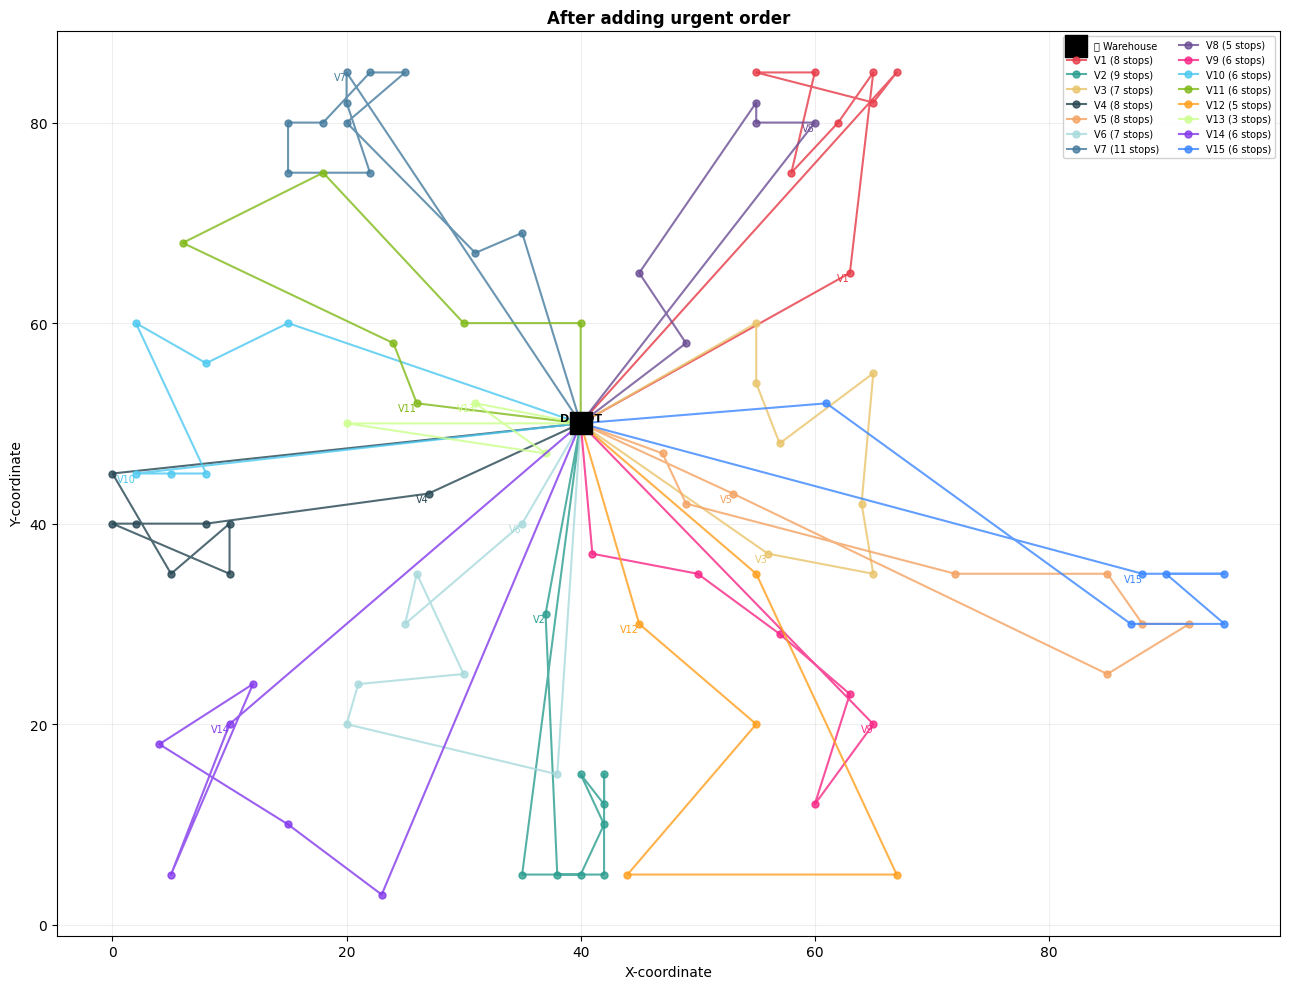

In [15]:
# ── 15. 🆕 Dynamic Order Addition (Real-time Dispatch) ────────────────────────
#
# Simulates a customer calling in a new delivery order AFTER the
# initial route plan has been created — just like FarEye or Lalamove.

inst   = RC1_INSTANCES[0].copy() if hasattr(RC1_INSTANCES[0], 'copy') else RC1_INSTANCES[0]
engine = DispatchEngine(inst, CFG)

# Step 1: initial plan
print('STEP 1: Initial optimisation')
plan1 = engine.optimise('DQN→ALNS', seed=42)

# Step 2: customer calls with a new order
print('\nSTEP 2: New order received at 08:30!')
new_order = engine.add_order(
    x=55.0, y=35.0,          # location
    demand_kg=30.0,           # package weight
    earliest_hhmm='09:00',   # customer available from 09:00
    latest_hhmm='14:00',     # must deliver before 14:00
    service_min=20.0,
    customer_name='Siêu thị Coopmart Q3',
    priority='express',
    re_optimise=True,         # automatically re-routes!
)

print(f'\n✅ New order inserted: {new_order}')
visualise_plan(engine.current_plan, title='After adding urgent order')

In [16]:
# ── 16. Full Benchmark (RC1 + RC2, all 3 algorithms) ─────────────────────────
# ⚠️  This takes ~2–4 hours on CPU, ~30–60 min on T4 GPU.
#     Comment out algorithms you don't need.

ALL_INSTANCES = RC1_INSTANCES + RC2_INSTANCES

df = run_benchmark(
    instances  = ALL_INSTANCES,
    algorithms = ['ALNS', 'DQN', 'DQN→ALNS'],
    cfg        = CFG,
)

print_benchmark_table(df)


[RC101] ALNS

🔧 Running ALNS on RC101...
✅ Done in 74.7s

📊 Dispatch Plan — ALNS
   🚛 Vehicles deployed:    16
   📏 Total distance:       168.5 km
   💰 Total cost:           4,042,400 VND
   📦 Cost/delivery:        40,023 VND
   ⏰ On-time rate:         100.0%
   📈 Avg vehicle load:     54.8%
   ✅ Feasible:             True
   📐 vs BKS:               TD -0.7% | NV +2
  → DispatchPlan(ALNS, nv=16, dist=168.5km, on_time=100.0%)

[RC101] DQN

🔧 Running DQN on RC101...
✅ Done in 2.4s

📊 Dispatch Plan — DQN
   🚛 Vehicles deployed:    34
   📏 Total distance:       379.7 km
   💰 Total cost:           8,698,600 VND
   📦 Cost/delivery:        86,124 VND
   ⏰ On-time rate:         100.0%
   📈 Avg vehicle load:     25.8%
   ✅ Feasible:             True
   📐 vs BKS:               TD +123.8% | NV +20
  → DispatchPlan(DQN, nv=34, dist=379.7km, on_time=100.0%)

[RC101] DQN→ALNS

🔧 Running DQN→ALNS on RC101...
✅ Done in 70.9s

📊 Dispatch Plan — DQN→ALNS
   🚛 Vehicles deployed:    15
   📏 Total distanc

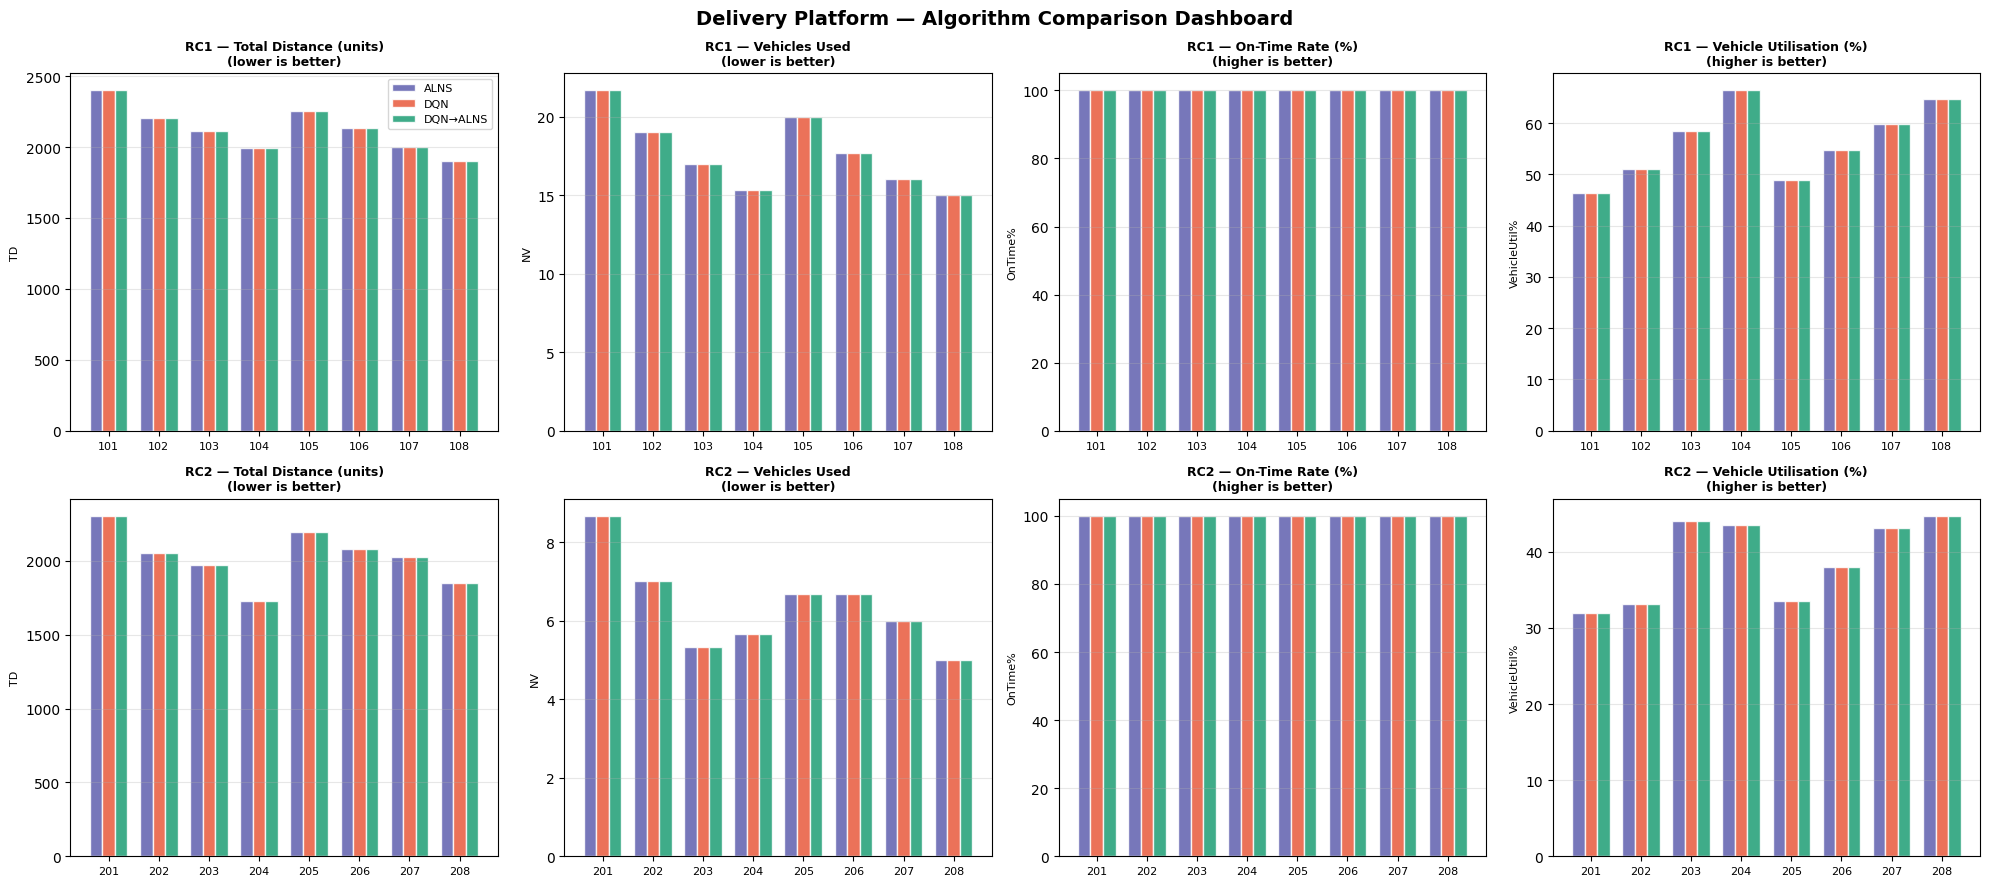

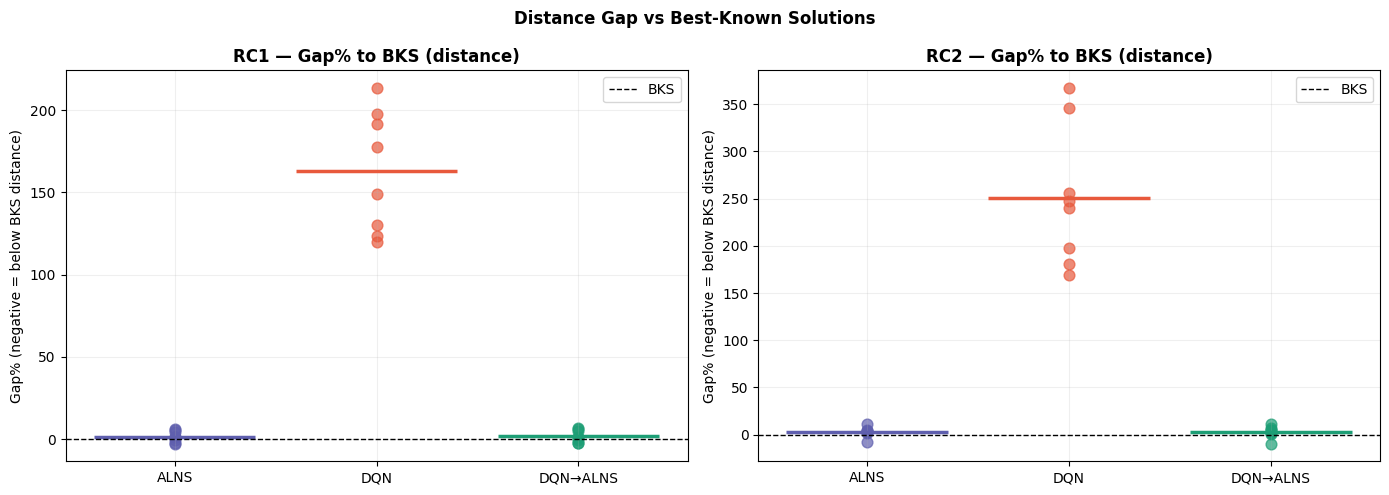

In [17]:
# ── 17. Results Dashboard ─────────────────────────────────────────────────────
def plot_dashboard(df: pd.DataFrame):
    COLORS = {'ALNS':'#5f5fae','DQN':'#e8593c','DQN→ALNS':'#1d9e75'}
    metrics = [
        ('TD',         'Total Distance (units)', 'lower is better'),
        ('NV',         'Vehicles Used',          'lower is better'),
        ('OnTime%',    'On-Time Rate (%)',        'higher is better'),
        ('VehicleUtil%','Vehicle Utilisation (%)','higher is better'),
    ]
    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    for row_idx, ds in enumerate(['RC1', 'RC2']):
        for col_idx, (metric, label, note) in enumerate(metrics):
            ax = axes[row_idx][col_idx]
            sub = df[df['Dataset']==ds]
            insts = sub['Instance'].unique()
            x, w = np.arange(len(insts)), 0.25
            for j, (algo, col) in enumerate(COLORS.items()):
                if algo not in sub['Algorithm'].values: continue
                vals = [sub[sub['Instance']==i][metric].mean() for i in insts]
                ax.bar(x + j*w, vals, w, label=algo, color=col, alpha=0.85, edgecolor='white')
            ax.set_xticks(x + w); ax.set_xticklabels([i[-3:] for i in insts], fontsize=8)
            ax.set_title(f'{ds} — {label}\n({note})', fontsize=9, fontweight='bold')
            ax.set_ylabel(metric, fontsize=8)
            ax.grid(axis='y', alpha=0.3)
            if row_idx==0 and col_idx==0: ax.legend(fontsize=8)

    plt.suptitle('Delivery Platform — Algorithm Comparison Dashboard',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'dashboard.png'), dpi=150, bbox_inches='tight')
    plt.show()


def plot_cost_distribution(df: pd.DataFrame):
    COLORS = {'ALNS':'#5f5fae','DQN':'#e8593c','DQN→ALNS':'#1d9e75'}
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, ds in zip(axes, ['RC1','RC2']):
        sub = df[df['Dataset']==ds]
        for algo, col in COLORS.items():
            data = sub[sub['Algorithm']==algo]['Gap%'].dropna()
            if len(data) > 0:
                ax.scatter([algo]*len(data), data, color=col, alpha=0.7, s=60)
                ax.hlines(data.mean(), -0.4+list(COLORS).index(algo),
                          0.4+list(COLORS).index(algo), color=col, linewidth=2.5)
        ax.axhline(0, color='black', linestyle='--', linewidth=1, label='BKS')
        ax.set_title(f'{ds} — Gap% to BKS (distance)', fontweight='bold')
        ax.set_ylabel('Gap% (negative = below BKS distance)')
        ax.legend(); ax.grid(alpha=0.2)
    plt.suptitle('Distance Gap vs Best-Known Solutions', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'gap_plot.png'), dpi=150, bbox_inches='tight')
    plt.show()


# Load results and plot (run after benchmark)
result_path = os.path.join(OUTPUT_DIR, 'benchmark_results.csv')
if os.path.exists(result_path):
    df = pd.read_csv(result_path)
    plot_dashboard(df)
    plot_cost_distribution(df)
else:
    print('⚠️  Run cell 16 (benchmark) first.')

In [18]:
# ── 18. Save / Load Models ────────────────────────────────────────────────────

def save_fleet_models(instances: List[LogisticsInstance],
                      cfg: PlatformConfig = CFG):
    """Train and save a DQN model for each instance (for demo deployment)."""
    for inst in instances:
        solver = DQNALNSSolver(inst, cfg)
        plan, _ = solver.solve(seed=cfg.seed)
        path = os.path.join(MODEL_DIR, f'dqn_{inst.name}.safetensors')
        solver.save(path)
        print(f'  💾 Saved {inst.name}: nv={plan.nv}, dist={plan.total_distance_km:.1f}km → {path}')

def load_and_run(inst: LogisticsInstance, model_path: str,
                 cfg: PlatformConfig = CFG) -> DispatchPlan:
    """
    Load a pre-trained DQN and run the full DQN→ALNS pipeline.
    Used in production / demo mode without re-training.
    """
    solver = DQNALNSSolver(inst, cfg)
    solver.load(model_path)
    plan, _ = solver.alns.solve(seed=cfg.seed)  # ALNS only, DQN already trained
    plan.algorithm = 'DQN→ALNS (pre-trained)'
    return plan

# Uncomment to save models for all RC1 instances:
# save_fleet_models(RC1_INSTANCES, CFG)

print('✅ Model save/load utilities ready.')

✅ Model save/load utilities ready.


## 📋 Quick Reference — Platform API

```python
# ── Load an instance ─────────────────────────────────────────────
inst   = RC1_INSTANCES[0]   # RC101
engine = DispatchEngine(inst, CFG)

# ── Run optimisation ─────────────────────────────────────────────
plan = engine.optimise('DQN→ALNS', seed=42)  # recommended
plan = engine.optimise('ALNS',     seed=42)  # baseline
plan = engine.optimise('DQN',      seed=42)  # constructive only

# ── View results ─────────────────────────────────────────────────
plan.kpi_summary()                  # business metrics
visualise_plan(plan)                # route map
print_driver_schedule(plan, v=0)    # driver card

# ── Compare algorithms ───────────────────────────────────────────
compare_plans(plan_alns, plan_dqn, plan_hybrid)

# ── Add a new order dynamically ──────────────────────────────────
engine.add_order(
    x=55, y=35, demand_kg=30,
    earliest_hhmm='09:00', latest_hhmm='14:00',
    customer_name='KH mới', re_optimise=True
)

# ── Full benchmark ───────────────────────────────────────────────
df = run_benchmark(RC1_INSTANCES + RC2_INSTANCES)
print_benchmark_table(df)
```

---
### 🗂️ Algorithm Flow
```
DQN→ALNS (recommended):
  Phase 1 — DQN Constructor
    • Builds routes stop-by-stop
    • State: 13 features incl. TW slack, urgency
    • Reward: distance + TW urgency bonus
    → Produces warm-start DispatchPlan

  Phase 2 — ALNS Refinement
    • Starts from DQN warm-start (not random!)
    • 5 destroy × 4 repair = 20 operator combos
    • Adaptive weights learned per instance
    → Returns polished DispatchPlan
```